# Guided exercise, worked: the tier decomposition

**Week 0 foundations guide, Chapter 3, Numbers. Hands-on, 60 minutes.** Every placeholder is filled
with the code of the right letter or the right number, the notebook has been run from a clean
kernel, and a line under each step says why the other letters fail. Work through the guided notebook
before reading this one.

The letters for TODO 1 to 4, 9 and 10, in order: **c d a d c b**. The trace, TODO 5 to 8:
**724, 54_000, 760, 62_000**.

**The setup this notebook needs.** Nothing beyond the programme's helper: the table is typed into a
cell, and no database is used.

The next cell finds the programme's helper, `scripts/c2kit.py`, by walking up from this folder,
and draws where this exercise sits among the guide's eight.

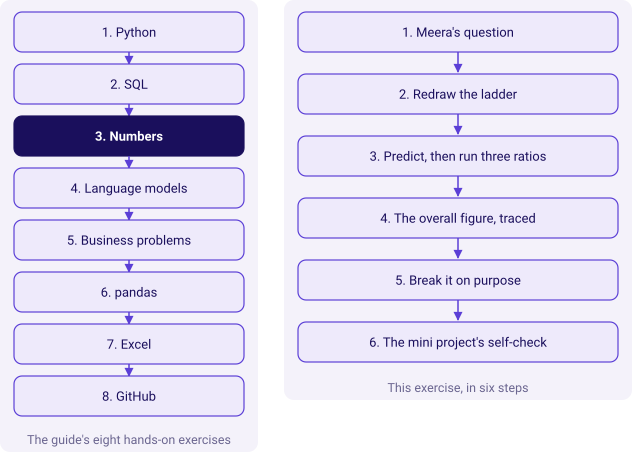

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

kit.side_by_side(
    kit.ladder(["Python", "SQL", "Numbers", "Language models", "Business problems", "pandas",
                "Excel", "GitHub"], lit=2, title="The guide's eight hands-on exercises", show=False),
    kit.vflow(["1. Meera's question", "2. Redraw the ladder", "3. Predict, then run three ratios",
               "4. The overall figure, traced", "5. Break it on purpose", "6. The mini project's self-check"],
              title="This exercise, in six steps", show=False),
)

## Step 1. Meera's question, and the table (3 minutes)

Meera Raghavan, CEO of Kalpa Retail:

> "Revenue fell from Q1 to Q2, where did it go?"

Chapter 3 puts its ladder under her question. Kalpa had 7,000 more customers in Q2 and 44 lakh less
revenue, so revenue per customer fell, and this exercise asks how much of that fall happened inside
the tiers and how much came from which tiers the customers are in. The table is the diagnostic
case's, from Q29 to Q32, with revenue in Rs lakh; Kalpa Retail is the programme's fictional company.

In [2]:
# The Kalpa Q1 and Q2 table from the diagnostic case, Q29 to Q32. Revenue is in Rs lakh.
TIERS = ("Plus", "Basic", "Student")
LAKH = 100_000
kalpa = {
    "Plus":    {"Q1": {"customers": 10_000, "orders": 30_000, "revenue": 360},
                "Q2": {"customers": 10_000, "orders": 27_000, "revenue": 324}},
    "Basic":   {"Q1": {"customers": 40_000, "orders": 60_000, "revenue": 420},
                "Q2": {"customers": 44_000, "orders": 64_000, "revenue": 400}},
    "Student": {"Q1": {"customers": 5_000, "orders": 6_000, "revenue": 24},
                "Q2": {"customers": 8_000, "orders": 9_000, "revenue": 36}},
    "Total":   {"Q1": {"customers": 55_000, "orders": 96_000, "revenue": 804},
                "Q2": {"customers": 62_000, "orders": 100_000, "revenue": 760}},
}
print(f"{len(TIERS)} tiers and the Total row, each with customers, orders and revenue in two quarters")

3 tiers and the Total row, each with customers, orders and revenue in two quarters


In [3]:
kit.table(["tier", "Q1 customers", "Q1 orders", "Q1 revenue", "Q2 customers", "Q2 orders", "Q2 revenue"],
          [(t, *(f"{kalpa[t][q][f]:,}" for q in ("Q1", "Q2") for f in ("customers", "orders", "revenue")))
           for t in (*TIERS, "Total")],
          caption="The case table, revenue in Rs lakh")
adds_up = all(sum(kalpa[t][q][f] for t in TIERS) == kalpa["Total"][q][f]
              for q in ("Q1", "Q2") for f in ("customers", "orders", "revenue"))
kit.check("the three tiers add up to the Total row in every column", adds_up)
kit.check("revenue fell 44 lakh while the customer count grew by 7,000",
          kalpa["Total"]["Q2"]["revenue"] - kalpa["Total"]["Q1"]["revenue"] == -44
          and kalpa["Total"]["Q2"]["customers"] - kalpa["Total"]["Q1"]["customers"] == 7_000)

tier,Q1 customers,Q1 orders,Q1 revenue,Q2 customers,Q2 orders,Q2 revenue
Plus,"10,000","30,000",360,"10,000","27,000",324
Basic,"40,000","60,000",420,"44,000","64,000",400
Student,"5,000","6,000",24,"8,000","9,000",36
Total,"55,000","96,000",804,"62,000","100,000",760


## Step 2. Redraw the ladder (4 minutes)

Before any ratio, draw the chapter's picture on paper from memory: the denominator ladder, four rungs
from the bottom up, each fixing the mistake the rung below invites, with one example on each rung.
Then run the next cell and compare.

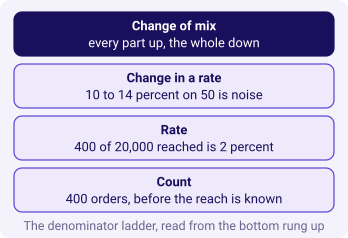

In [4]:
kit.stack(["Count\n400 orders, before the reach is known",
           "Rate\n400 of 20,000 reached is 2 percent",
           "Change in a rate\n10 to 14 percent on 50 is noise",
           "Change of mix\nevery part up, the whole down"],
          lit=3, title="The denominator ladder, read from the bottom rung up")

The chapter rings Rate; the top rung is lit here because the mini project ends on it. Meera's
question touches all four rungs: 55,000 and 62,000 are counts, revenue per customer is a rate, its fall
is a change in a rate, and the part of that fall that comes from where the customers sit is a change
of mix.

## Step 3. Predict, then run: three ratios for each tier (15 minutes)

Each tier's revenue per customer is two ratios multiplied: how many orders a customer places, and
what one order is worth. Computing all three in both quarters shows which of them moved. Revenue is
in lakh, so it is multiplied by `LAKH` to give rupees.

In [5]:
# PREDICT, TODO 1. Plus lost the most revenue, 36 lakh. Which tier's revenue per customer fell
# the most, in percent?
#   a) "Plus"
#   b) "all about equally"
#   c) "Basic"
#   d) "none"
steepest_prediction = "Basic"
print("Your prediction:", steepest_prediction)

Your prediction: Basic


In [6]:
def ratios(q):
    """Revenue per customer, orders per customer and revenue per order, for one tier in one quarter."""
    return {
        # TODO 2. Which expression gives revenue per customer in rupees?
        #   a) q["revenue"] / q["customers"]
        #   b) q["customers"] * LAKH / q["revenue"]
        #   c) q["revenue"] * LAKH / q["orders"]
        #   d) q["revenue"] * LAKH / q["customers"]
        "revenue_per_customer": q["revenue"] * LAKH / q["customers"],
        # TODO 3. Which expression gives orders per customer?
        #   a) q["orders"] / q["customers"]
        #   b) q["orders"] // q["customers"]
        #   c) q["customers"] / q["orders"]
        #   d) q["orders"] * LAKH / q["customers"]
        "orders_per_customer": q["orders"] / q["customers"],
        "revenue_per_order": q["revenue"] * LAKH / q["orders"],
    }


r = {t: {q: ratios(kalpa[t][q]) for q in ("Q1", "Q2")} for t in TIERS}
print("Rs per customer in Q2:", {t: round(r[t]["Q2"]["revenue_per_customer"], 2) for t in TIERS})

Rs per customer in Q2: {'Plus': 3240.0, 'Basic': 909.09, 'Student': 450.0}


tier,"Rs per customer, Q1",Q2,"orders per customer, Q1",Q2,"Rs per order, Q1",Q2
Plus,"3,600.00","3,240.00",3.00,2.70,"1,200.00","1,200.00"
Basic,"1,050.00",909.09,1.50,1.45,700.00,625.00
Student,480.00,450.00,1.20,1.12,400.00,400.00


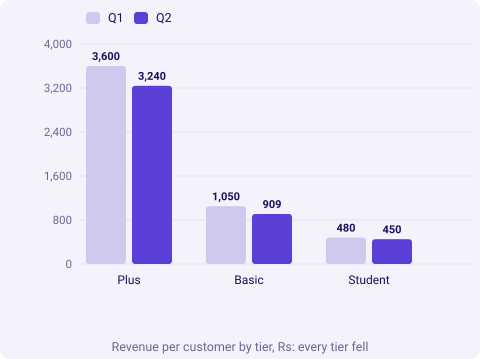

In [7]:
kit.table(["tier", "Rs per customer, Q1", "Q2", "orders per customer, Q1", "Q2", "Rs per order, Q1", "Q2"],
          [(t, *(f"{r[t][q][k]:,.2f}" for k in ("revenue_per_customer", "orders_per_customer",
                                                "revenue_per_order") for q in ("Q1", "Q2")))
           for t in TIERS],
          caption="Three ratios per tier, in both quarters")
kit.columns(list(TIERS), [("Q1", [r[t]["Q1"]["revenue_per_customer"] for t in TIERS]),
                          ("Q2", [r[t]["Q2"]["revenue_per_customer"] for t in TIERS])],
            title="Revenue per customer by tier, Rs: every tier fell", width=480)

In [8]:
change = {t: r[t]["Q2"]["revenue_per_customer"] / r[t]["Q1"]["revenue_per_customer"] - 1 for t in TIERS}
steepest = min(change, key=change.get)
kit.check("your prediction of the steepest fall per customer matches", steepest_prediction == steepest,
          f"you said {steepest_prediction!r}; the steepest is {steepest}, {100 * change[steepest]:.1f} percent")
kit.check("Plus brings in Rs 3,600 per customer in Q1 and Rs 3,240 in Q2",
          (round(r["Plus"]["Q1"]["revenue_per_customer"]), round(r["Plus"]["Q2"]["revenue_per_customer"]))
          == (3600, 3240))
kit.check("Basic customers placed 1.50 orders each in Q1 and 1.45 in Q2",
          (round(r["Basic"]["Q1"]["orders_per_customer"], 2), round(r["Basic"]["Q2"]["orders_per_customer"], 2))
          == (1.5, 1.45))

**Why, TODO 1:** c holds. Basic's revenue fell only 20 lakh while its customers grew from 40,000 to
44,000, so each customer brought in Rs 909 against Rs 1,050, a fall of 13.4 percent; Plus fell 10
percent and Student 6.25 percent. a answers the lakh question rather than the per-customer one; b
flattens a range from 6.25 to 13.4 percent into one figure, the move Step 5 stages as the trap; d
misses that Student's revenue rose only because its customers did, and per customer it fell too.

**Why, TODO 2:** d holds. a leaves revenue in lakh, so Plus reads 0.036 per customer; b turns the
ratio upside down; c divides by orders, which gives revenue per order.

**Why, TODO 3:** a holds. b is whole-number division, so Basic's 1.5 becomes 1 and Student's 1.2
becomes 1; c is customers per order; d multiplies a count by `LAKH`, which belongs on revenue only.

## Step 4. The overall figure, traced (12 minutes)

The overall revenue per customer is total revenue over total customers, and the loop below builds both
totals one tier at a time. Before running it, predict the overall fall, then fill in the trace by hand
from the table: the running Q2 revenue and customer count after each tier is added.

In [9]:
# PREDICT, TODO 4. Tier by tier, revenue per customer fell 10, 13.4 and 6.25 percent. By how
# much did the overall revenue per customer fall, to the nearest whole percent?
#   a) 6
#   b) 10
#   c) 13
#   d) 16
overall_fall_prediction = 16
print("Your prediction:", overall_fall_prediction, "percent")

Your prediction: 16 percent


In [10]:
# TODO 5 to 8. Your trace of the loop below for Q2, filled in by hand from the table:
# (the tier just added, running revenue in Rs lakh, running customers)
my_trace = [
    ("Plus", 324, 10_000),
    ("Basic", 724, 54_000),
    ("Student", 760, 62_000),
]
for row in my_trace:
    print(row)

('Plus', 324, 10000)
('Basic', 724, 54000)
('Student', 760, 62000)


In [11]:
totals = {"Q1": {"revenue": 0, "customers": 0}, "Q2": {"revenue": 0, "customers": 0}}
real_trace = []
for t in TIERS:
    for q in ("Q1", "Q2"):
        totals[q]["revenue"] += kalpa[t][q]["revenue"]
        totals[q]["customers"] += kalpa[t][q]["customers"]
    real_trace.append((t, totals["Q2"]["revenue"], totals["Q2"]["customers"]))

overall = {q: totals[q]["revenue"] * LAKH / totals[q]["customers"] for q in ("Q1", "Q2")}
overall_fall = 100 * (1 - overall["Q2"] / overall["Q1"])
print(f"Overall revenue per customer: Rs {overall['Q1']:,.2f} in Q1 and Rs {overall['Q2']:,.2f} in Q2, "
      f"a fall of {overall_fall:.1f} percent")

Overall revenue per customer: Rs 1,461.82 in Q1 and Rs 1,225.81 in Q2, a fall of 16.1 percent


In [12]:
kit.table(["after adding", "your revenue", "your customers", "the loop's revenue", "the loop's customers"],
          [(m[0], m[1], m[2], x[1], x[2]) for m, x in zip(my_trace, real_trace)],
          caption="The running Q2 totals, yours beside the loop's")

after adding,your revenue,your customers,the loop's revenue,the loop's customers
Plus,324,10000,324,10000
Basic,724,54000,724,54000
Student,760,62000,760,62000


In [13]:
kit.check("your trace matches the loop after every tier", my_trace == real_trace,
          f"{sum(m == x for m, x in zip(my_trace, real_trace))} of 3 rows match")
kit.check("your prediction of the overall fall matches, to the nearest percent",
          overall_fall_prediction == round(overall_fall),
          f"you said {overall_fall_prediction}; it fell {overall_fall:.1f} percent")
kit.check("the loop's totals equal the table's Total row",
          all(totals[q][f] == kalpa["Total"][q][f] for q in ("Q1", "Q2") for f in ("revenue", "customers")))

**Why, TODO 4:** d holds. Rs 1,461.82 to Rs 1,225.81 is a fall of 16.1 percent, steeper than any
tier's own fall. a and b sit inside the range of the tiers' falls, which is where intuition puts an
average; c is Basic's fall, the steepest tier, and the overall fell further than that.

**Why, the trace:** Basic adds 400 lakh and 44,000 customers to Plus's 324 and 10,000, giving 724 and
54,000; Student adds 36 and 8,000, which lands on 760 and 62,000, the table's Total row.

## Step 5. Break it on purpose: the averaged ratios (18 minutes)

The tempting change: three tiers each have a revenue-per-customer figure already computed, so the
overall looks like their average, with no totals needed. Run it, read the number it gives, and read
the check.

In [14]:
averaged = {q: sum(r[t][q]["revenue_per_customer"] for t in TIERS) / len(TIERS) for q in ("Q1", "Q2")}
averaged_fall = 100 * (1 - averaged["Q2"] / averaged["Q1"])
kit.table(["method", "Q1, Rs", "Q2, Rs", "fall"],
          [("the three tiers' figures, averaged", f"{averaged['Q1']:,.2f}", f"{averaged['Q2']:,.2f}",
            f"{averaged_fall:.1f} percent"),
           ("total revenue over total customers", f"{overall['Q1']:,.2f}", f"{overall['Q2']:,.2f}",
            f"{overall_fall:.1f} percent")],
          caption="One overall figure, computed two ways")

method,"Q1, Rs","Q2, Rs",fall
"the three tiers' figures, averaged","1,710.00","1,533.03",10.3 percent
total revenue over total customers,"1,461.82","1,225.81",16.1 percent


**The plausible wrong answer.** Rs 1,710 in Q1 and Rs 1,533 in Q2, a fall of 10.3 percent, which
sits inside the tiers' own falls and reads as "every tier fell by about a tenth". That answer drives a
uniform response: treat Q2 as a spending slowdown and push spending back up in all three tiers alike.

**Why it is wrong.** Averaging the three figures gives Student's 5,000 customers the same weight as
Basic's 40,000. The weighted figure, total revenue over total customers, fell 16.1 percent, more than
any single tier fell, and the part no tier explains is mix: the new customers joined the cheaper
tiers. That answer drives a split response: the fall inside the tiers is a spending question, the mix
is a question about which customers Kalpa is gaining, and pulling every tier back to its Q1 spending
would still leave revenue per customer below Q1, which Step 6 checks.

In [15]:
kit.check("the check that catches it: the overall Q1 figure has to be 804 lakh over 55,000 customers",
          abs(overall["Q1"] - 804 * LAKH / 55_000) < 1e-9 and abs(averaged["Q1"] - 804 * LAKH / 55_000) > 1,
          f"weighted Rs {overall['Q1']:,.2f}; averaged Rs {averaged['Q1']:,.2f}")
steepest_tier_fall = max(-100 * change[t] for t in TIERS)
kit.check("the weighted figure fell further than any tier did, which an average of the tiers never can",
          overall_fall > steepest_tier_fall > averaged_fall,
          f"overall {overall_fall:.1f}, steepest tier {steepest_tier_fall:.1f}, averaged {averaged_fall:.1f}")

**The fix, and the mix it shows.** Weight each tier's figure by its share of the customers, which is
what total over total does. Holding Q1's shares and using Q2's figure inside each tier gives the fall
the tiers alone explain; the rest of the 16.1 percent is mix. The next cell computes that and prints
the mini project's one table.

In [16]:
share = {q: {t: kalpa[t][q]["customers"] / kalpa["Total"][q]["customers"] for t in TIERS} for q in ("Q1", "Q2")}

# TODO 9. Which line gives the overall figure Q2 would have had if customers had kept Q1's mix?
#   a) sum(share["Q2"][t] * r[t]["Q1"]["revenue_per_customer"] for t in TIERS)
#   b) sum(r[t]["Q2"]["revenue_per_customer"] for t in TIERS) / len(TIERS)
#   c) sum(share["Q1"][t] * r[t]["Q2"]["revenue_per_customer"] for t in TIERS)
#   d) sum(share["Q1"][t] * r[t]["Q1"]["revenue_per_customer"] for t in TIERS)
q2_at_q1_mix = sum(share["Q1"][t] * r[t]["Q2"]["revenue_per_customer"] for t in TIERS)
within = q2_at_q1_mix - overall["Q1"]
mix = overall["Q2"] - q2_at_q1_mix

print(f"{'':38}{'Q1':>9}{'Q2':>9}{'change':>10}")
for t in TIERS:
    a, b = r[t]["Q1"]["revenue_per_customer"], r[t]["Q2"]["revenue_per_customer"]
    print(f"{t + ', Rs per customer':38}{a:>9,.0f}{b:>9,.0f}{100 * (b / a - 1):>9.2f}%")
print(f"{'Overall at Q1 mix, tier changes only':38}{overall['Q1']:>9,.0f}{q2_at_q1_mix:>9,.0f}"
      f"{100 * (q2_at_q1_mix / overall['Q1'] - 1):>9.2f}%")
print(f"{'Overall as reported':38}{overall['Q1']:>9,.0f}{overall['Q2']:>9,.0f}"
      f"{100 * (overall['Q2'] / overall['Q1'] - 1):>9.2f}%")
print(f"{'The difference, which is mix':38}{'':>9}{mix:>9,.0f}{100 * mix / overall['Q1']:>9.2f}%")

                                             Q1       Q2    change
Plus, Rs per customer                     3,600    3,240   -10.00%
Basic, Rs per customer                    1,050      909   -13.42%
Student, Rs per customer                    480      450    -6.25%
Overall at Q1 mix, tier changes only      1,462    1,291   -11.67%
Overall as reported                       1,462    1,226   -16.15%
The difference, which is mix                         -65    -4.47%


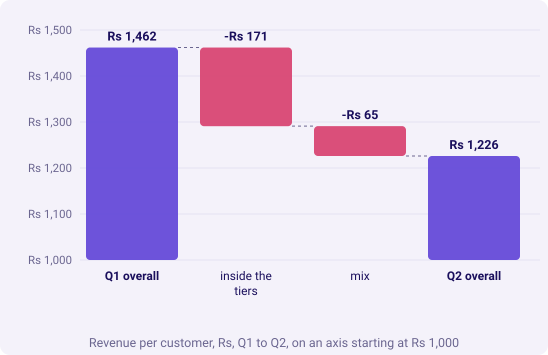

In [17]:
kit.check("the fall inside the tiers and the mix add up exactly to the reported fall",
          abs(within + mix - (overall["Q2"] - overall["Q1"])) < 1e-9, f"{within:,.2f} + {mix:,.2f}")
kit.check("mix costs about Rs 65 of the Rs 236 fall per customer",
          round(mix) == -65 and round(overall["Q2"] - overall["Q1"]) == -236, f"mix Rs {mix:,.2f}")
kit.bridge(("Q1 overall", round(overall["Q1"])), [("inside the tiers", round(within)), ("mix", round(mix))],
           end_label="Q2 overall", title="Revenue per customer, Rs, Q1 to Q2, on an axis starting at Rs 1,000",
           lo=1000)

**Why, TODO 9:** c holds: Q1's customer shares with Q2's figure inside each tier. a is the opposite
what-if, Q2's shares with Q1's figures, which Step 6 uses; b is the averaged answer again; d rebuilds
Q1's own overall, Rs 1,461.82, because it changes nothing.

## Step 6. The mini project's self-check (8 minutes)

The guide's three self-check lines, as checks. The third is a what-if: Student's Q2 customer count
changes while each Student customer keeps behaving as the table says, so Student's orders and revenue
move in step with its customers.

In [18]:
# PREDICT, TODO 10. Had Student stayed at 5,000 customers in Q2, each spending as the table's
# Student customers did, the overall Q2 revenue per customer would have come out:
#   a) "lower"
#   b) "higher"
#   c) "unchanged"
#   d) "back at Q1"
what_if_prediction = "higher"
print("Your prediction:", what_if_prediction)

Your prediction: higher


In [19]:
def overall_q2(table, student_customers):
    """Q2 revenue per customer with Student's customer count set, each Student customer unchanged."""
    s = table["Student"]["Q2"]
    scale = student_customers / s["customers"]
    q2 = {t: dict(table[t]["Q2"]) for t in TIERS}
    q2["Student"] = {f: s[f] * scale for f in ("customers", "orders", "revenue")}
    revenue = sum(q2[t]["revenue"] for t in TIERS)
    customers = sum(q2[t]["customers"] for t in TIERS)
    return revenue * LAKH / customers, {t: ratios(q2[t]) for t in TIERS}


as_reported, ratios_reported = overall_q2(kalpa, 8_000)
fewer_students, ratios_fewer = overall_q2(kalpa, 5_000)
print(f"Q2 overall: Rs {as_reported:,.2f} as reported, Rs {fewer_students:,.2f} with 5,000 Student customers")

Q2 overall: Rs 1,225.81 as reported, Rs 1,265.25 with 5,000 Student customers


In [20]:
multiply_back = all(abs(r[t][q]["orders_per_customer"] * r[t][q]["revenue_per_order"]
                        - r[t][q]["revenue_per_customer"]) < 1e-6 for t in TIERS for q in ("Q1", "Q2"))
kit.check("self-check 1: in every tier, orders per customer times revenue per order gives revenue per customer",
          multiply_back)
kit.check("self-check 2: the overall figure for Q1 is 804 divided by 55,000",
          abs(overall["Q1"] - 804 * LAKH / 55_000) < 1e-9, f"Rs {overall['Q1']:,.2f}")
unchanged = all(abs(ratios_fewer[t][k] - ratios_reported[t][k]) < 1e-9 for t in TIERS for k in ratios_reported[t])
kit.check("self-check 3: changing the Student count moves the overall figure and no tier's own ratios",
          abs(fewer_students - as_reported) > 1 and unchanged,
          f"the overall moves by Rs {fewer_students - as_reported:,.2f}; every tier's ratios unchanged: {unchanged}")
moved = "higher" if fewer_students > as_reported else "lower" if fewer_students < as_reported else "unchanged"
kit.check("your prediction of the what-if matches", what_if_prediction == moved,
          f"you said {what_if_prediction!r}; it came out {moved}")
back_at_q1 = sum(share["Q2"][t] * r[t]["Q1"]["revenue_per_customer"] for t in TIERS)
kit.check("with every tier back at its Q1 figure, Q2's customer mix alone keeps the overall below Q1's",
          back_at_q1 < overall["Q1"], f"Rs {back_at_q1:,.2f} against Rs {overall['Q1']:,.2f}")

In [21]:
kit.check_summary()

**Why, TODO 10:** b holds. A Student customer brings in Rs 450, well under the Rs 1,226 overall, so
fewer of them lift the overall: Rs 1,265.25 with 5,000 against Rs 1,225.81 with 8,000, while no
tier's own ratios move. a has the effect of the weights backwards; c would need an overall that
ignores its weights; d would need every tier's own figure back at Q1 as well.

## What you would now say to Meera

"Revenue per customer fell 16 percent, from Rs 1,462 to Rs 1,226, which is more than any tier fell on
its own. About Rs 65 of the Rs 236 is mix, because the new customers joined Basic and Student, which
bring in less per customer, and the other Rs 171 is spending falling inside the tiers."

## Into your `w00-diagnostic-numbers` repository

Chapter 8 shows how to create the repository. In a notebook there, copy five cells in order, none of
which needs the helper: the table from Step 1, the `ratios` cell from Step 3, the loop from Step 4,
the cell that prints the one table from Step 5, and the `overall_q2` cell from Step 6. The helper is
not in your repository, so the self-check becomes these lines:

```python
assert all(abs(r[t][q]["orders_per_customer"] * r[t][q]["revenue_per_order"]
               - r[t][q]["revenue_per_customer"]) < 1e-6 for t in TIERS for q in ("Q1", "Q2"))
assert abs(overall["Q1"] - 804 * LAKH / 55_000) < 1e-9
fewer, reported = overall_q2(kalpa, 5_000), overall_q2(kalpa, 8_000)
assert fewer[0] != reported[0]
assert all(abs(fewer[1][t][k] - reported[1][t][k]) < 1e-9 for t in TIERS for k in reported[1][t])
```

Paste the printed table under the README's Result heading, with your sentence to Meera above it, and
post the repository's link in the Week 0 thread on Discussions, as the guide's path asks.